Advanced Modeling of the VSTOXX Index

square-root jump diffusion (SRJD) to model the VSTOXX volatility index. The model, which is essentially an extension of the Gruenbichler and Longstaff (1996) model as analyzed in the previous chapter, is capable of reproducing prices of European options written on the VSTOXX reasonably well.

Two major enhancements characterize the SRJD model:

term structure: it allows to capture the term structure as observed in the prices of futures on the VSTOXX index
jump component: including a jump component allows to better replicate option prices in the short term
Adding these two components makes a market-consistent calibration of the model to a comprehensive set of European options on the VSTOXX index possible.

In [4]:
import numpy as np
import pandas as pd
np.set_printoptions(suppress=True)
import matplotlib.pyplot as plt
from openbb import obb
import yfinance as yf
from datetime import datetime as dt
from tqdm  import tqdm

In [37]:
date=pd.to_datetime(dt.now())
date = date.strftime("%Y-%m-%d")
print(date)

2024-01-15


In [38]:
#Collection of Option Chain over all available maturities
VIX = yf.Ticker("^VIX")
S0 = VIX.history(date)["Close"].values[0]

# get Expiration Dates
expiration_dates = VIX.options[1:]
print(expiration_dates)
print(S0)


('2024-01-24', '2024-01-31', '2024-02-07', '2024-02-14', '2024-02-21', '2024-03-20', '2024-04-17', '2024-05-22', '2024-06-18', '2024-07-17', '2024-08-21', '2024-09-18')
13.25


In [39]:
# Step 3: get option chain for each expiration date
df = []
for expiration_date in tqdm(expiration_dates, desc='Collecting Option Data'):
    # Collect all Calls
    _df = VIX.option_chain(expiration_date).calls
    _df['DaysSinceLastTraded'] = (pd.to_datetime(_df['lastTradeDate']).dt.tz_localize(None) - pd.to_datetime(dt.now())).dt.days
    _df = _df[_df['DaysSinceLastTraded'] > -14]
    _df['Weight'] = 1 / (_df['bid'] - _df['ask'])**2
    _df['price']  = (_df['bid'] + _df['ask'])/2
    _df['maturity'] = (pd.to_datetime(expiration_date) - pd.to_datetime(dt.now())).days / 365
    _df['Type']     = 'c'
    _df['S']        = S0
    df.append(_df)


df = pd.concat(df)
df = df[df['maturity'] > 0]

print(df)


         contractSymbol             lastTradeDate  strike  lastPrice   bid  \
0   VIXW240124C00010000 2024-01-03 20:55:33+00:00    10.0       4.80  3.00   
1   VIXW240124C00010500 2024-01-03 20:37:13+00:00    10.5       4.10  2.95   
2   VIXW240124C00011000 2024-01-12 15:04:19+00:00    11.0       2.45  2.46   
3   VIXW240124C00011500 2024-01-12 21:02:51+00:00    11.5       2.10  1.99   
4   VIXW240124C00012000 2024-01-12 20:28:43+00:00    12.0       1.62  1.49   
..                  ...                       ...     ...        ...   ...   
43   VIX240918C00100000 2024-01-09 19:28:12+00:00   100.0       0.23  0.00   
44   VIX240918C00110000 2024-01-03 15:57:43+00:00   110.0       0.27  0.00   
45   VIX240918C00130000 2024-01-12 15:08:57+00:00   130.0       0.17   NaN   
46   VIX240918C00150000 2024-01-10 16:52:59+00:00   150.0       0.11   NaN   
47   VIX240918C00170000 2024-01-08 16:30:32+00:00   170.0       0.14   NaN   

     ask  change  percentChange  volume  openInterest  impliedV

In [40]:
mats = sorted(set(df['maturity']))
mats

[0.021917808219178082,
 0.0410958904109589,
 0.06027397260273973,
 0.07945205479452055,
 0.09863013698630137,
 0.17534246575342466,
 0.25205479452054796,
 0.34794520547945207,
 0.42191780821917807,
 0.5013698630136987,
 0.5972602739726027,
 0.673972602739726]

In [41]:
#plot call option market quotes which are not too far in-the-money nor out-of-the-money

In [42]:
tol = 0.4
to_plot = df[(df['strike'] > (1 - tol) * S0)
                      & (df['strike'] < (1 + tol) * S0)]

In [43]:
#The figure shows the VSTOXX European call option quotes which fulfill the requirements. 
#The goal  is to replicate "all these option quotes" as good as possible.

Text(0, 0.5, 'option quote')

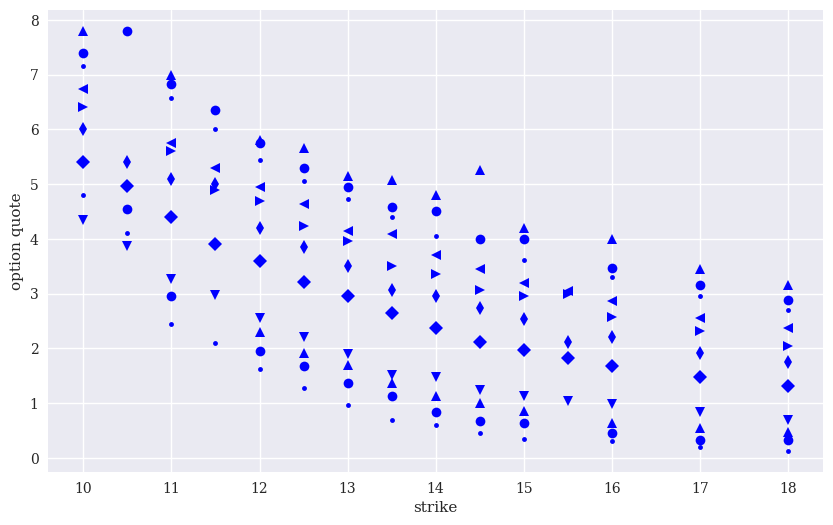

In [44]:

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
plt.rcParams['font.family'] = 'serif'
markers = ['.', 'o', '^', 'v', 'x', 'D', 'd', '>', '<']
plt.figure(figsize=(10, 6))
for i, mat in enumerate(mats):
    strikes = to_plot[(to_plot['maturity'] == mat)]['strike']
    prices = to_plot[(to_plot['maturity'] == mat)]['lastPrice']
    plt.plot(strikes, prices, 'b%s' % markers[i % len(markers)], label=str(mat)[:10])
#plt.legend()
plt.xlabel('strike')
plt.ylabel('option quote')


In [45]:
#The SRJD Model

Term Structure Calibration
The first in the calibration of the SRJD model, is with regard to the futures term structure.

Futures Term Structure
It is difficult for parsimonious short rate models like Cox et al. (1985) to account for different term structures of the interest rate. A possible solution is the introduction of time-dependent parameters which, however, enlarges the number of parameters significantly, sacrificing at the same time the convenience of a limited number of economic parameters. Another solution is a deterministic shift approach according to Brigo and Mercurio (2001) which preserves the basic structure of the model with all its advantages and which nevertheless allows to better account for different term structures of the short rate.

In this section, we transfer the deterministic shift approach for short rate models of Brigo and Mercurio (2001) to the SRJD model. Since the square-root diffusion and the jumps are not correlated, we can first apply the approach to the diffusion part and use this enhanced component later on in conjunction with the jump component.

Before  present the theory, a look at the VSTOXX futures data first.

In [55]:
import datetime

futures = obb.derivatives.futures.curve(symbol="VX").to_dataframe()
#date = pd.to_datetime(dt.now()).date()
print(date)
futures['TTM'] = (pd.to_datetime(futures['expiration']) - pd.Timestamp(date)) / np.timedelta64(1, 'D') / 365
print(futures)

2024-01-15
    expiration    price   symbol       TTM
0   2024-01-17  13.1811    VX/F4  0.005479
1   2024-01-24  13.4250  VX04/F4  0.024658
2   2024-01-31  13.7750  VX05/F4  0.043836
3   2024-02-07  14.2000  VX06/G4  0.063014
4   2024-02-14  14.4647    VX/G4  0.082192
5   2024-02-21  14.4647  VX08/G4  0.101370
6   2024-02-27  14.4647  VX09/G4  0.117808
7   2024-03-20  15.4504    VX/H4  0.178082
8   2024-04-17  16.1801    VX/J4  0.254795
9   2024-05-22  16.5414    VX/K4  0.350685
10  2024-06-18  16.8500    VX/M4  0.424658
11  2024-07-17  17.4000    VX/N4  0.504110
12  2024-08-21  17.5750    VX/Q4  0.600000
13  2024-09-18  17.8250    VX/U4  0.676712


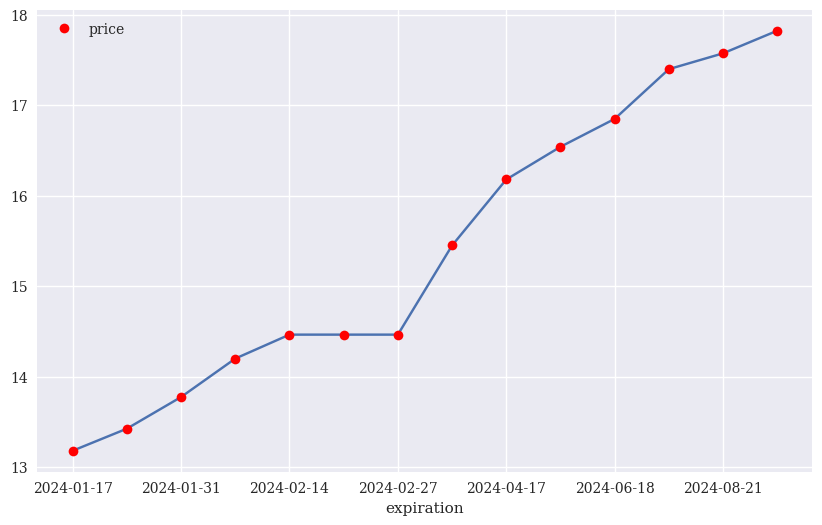

In [56]:
ax = futures.plot(x='expiration', y='price',
                         figsize=(10, 6), legend=False)
futures.plot(x='expiration', y='price', style='ro', ax=ax);

In [12]:
#calibrate the forward volatilities 
#to the VIX futures prices . 

In [59]:
import scipy.optimize as sco
import math

# selecting needed data columns and adding spot value
forwards = list(futures['price'].values)
forwards.insert(0, S0)
forwards = np.array(forwards)
ttms = list(futures['TTM'].values)
ttms.insert(0, 0)
ttms = np.array(ttms)


def srd_forwards(p0):
    ''' Function for forward volatilities in GL96 Model.

    Parameters
    ==========
    p0: list
        set of model parameters, where

        kappa: float
            mean-reversion factor
        theta: float
            long-run mean
        sigma: float
            volatility factor

    Returns
    =======
    forwards: NumPy ndarray object
        forward volatilities
    '''
    t = ttms
    kappa, theta, sigma = p0
    g = math.sqrt(kappa ** 2 + 2 * sigma ** 2)
    sum1 = ((kappa * theta * (np.exp(g * t) - 1)) /
            (2 * g + (kappa + g) * (np.exp(g * t) - 1)))
    sum2 = S0 * ((4 * g ** 2 * np.exp(g * t)) /
                 (2 * g + (kappa + g) * (np.exp(g * t) - 1)) ** 2)
    forwards = sum1 + sum2
    return forwards


def srd_fwd_error(p0):
    ''' Error function for GL96 forward volatilities calibration.

    Parameters
    ==========
    p0: tuple
        parameter vector

    Returns
    =======
    MSE: float
        mean-squared error for p0
    '''
    global i
    kappa, theta, sigma = p0
    srd_fwds = srd_forwards(p0)
    MSE = np.sum((forwards - srd_fwds) ** 2) / len(forwards)
    if 2 * kappa * theta < sigma ** 2:
        MSE = MSE + 100   # penalty
    elif sigma < 0:
        MSE = MSE + 100
    # print intermediate results: every 50th iteration
    if i % 50 == 0:
        print("{:6.3f} {:6.3f} {:6.3f}".format(*p0) + "{:>12.5f}".format(MSE))
    i += 1
    return MSE

if __name__ == '__main__':
    p0 = 1.0, 17.5, 1.0
    opt = sco.fmin(srd_fwd_error, p0,
                xtol=0.00001, ftol=0.00001,
                maxiter=1500, maxfun=2000)

 0.452 42.200  0.107     2.57272
 1.800 39.368  0.003     0.06287
 2.039 38.468 -0.000   100.05132
 2.040 38.463 -0.000   100.05133
 2.040 38.462  0.000     0.05133
 2.040 38.462  0.000     0.05133
Optimization terminated successfully.
         Current function value: 0.051335
         Iterations: 167
         Function evaluations: 308


In [60]:
opt.round(3)

array([ 2.04 , 38.462,  0.   ])

In [61]:
srd_fwds = srd_forwards(opt)
srd_fwds

array([13.25      , 13.31648618, 13.54342115, 13.7616486 , 13.97150265,
       14.17330458, 14.36736335, 14.52776204, 15.07194058, 15.67444531,
       16.3063557 , 16.71601283, 17.09232641, 17.47230492, 17.72706753])

In [62]:
srd_fwds - forwards

array([ 0.        ,  0.13538618,  0.11842115, -0.0133514 , -0.22849735,
       -0.29139542, -0.09733665,  0.06306204, -0.37845942, -0.50565469,
       -0.2350443 , -0.13398717, -0.30767359, -0.10269508, -0.09793247])

The following figure compares the model futures prices (forward volatilities) with the VSTOXX futures market quotes. For longer maturities the fit is quite well.

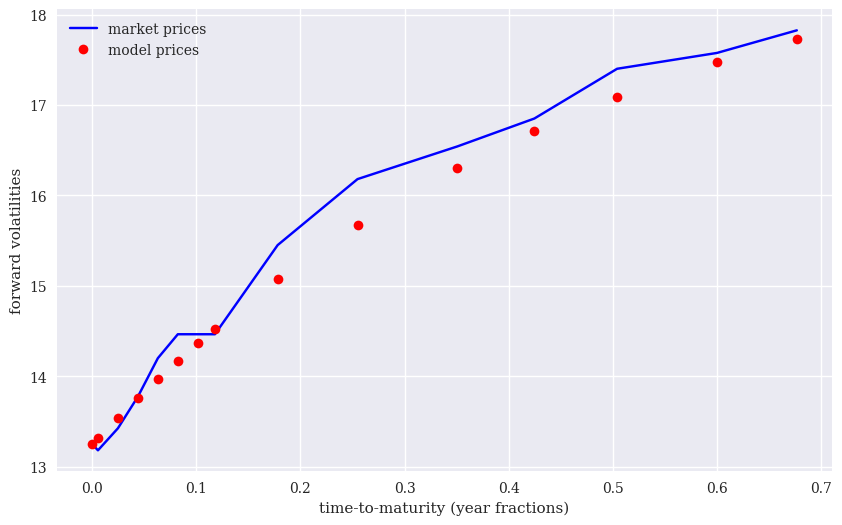

In [63]:
plt.figure(figsize=(10, 6));
plt.plot(ttms, forwards, 'b', label='market prices');
plt.plot(ttms, srd_fwds, 'ro', label='model prices');
plt.legend(loc=0);
plt.xlabel('time-to-maturity (year fractions)');
plt.ylabel('forward volatilities');

In [64]:
import pickle
f = open('varphi', 'wb')  # open file on disk
## write ttms object and differences (varphi values) as dictionary
pickle.dump({'ttms': ttms, 'varphi': srd_fwds - forwards}, f)
f.close()  # close file

Shifted Volatility Process


In [65]:
#Assume that we are given a continuously differentiable futures price function 
#(i.e. through splines interpolation of discrete futures prices for different maturities). 
#We consider now the deterministically shifted volatility process (see Brigo and Mercurio (2001))

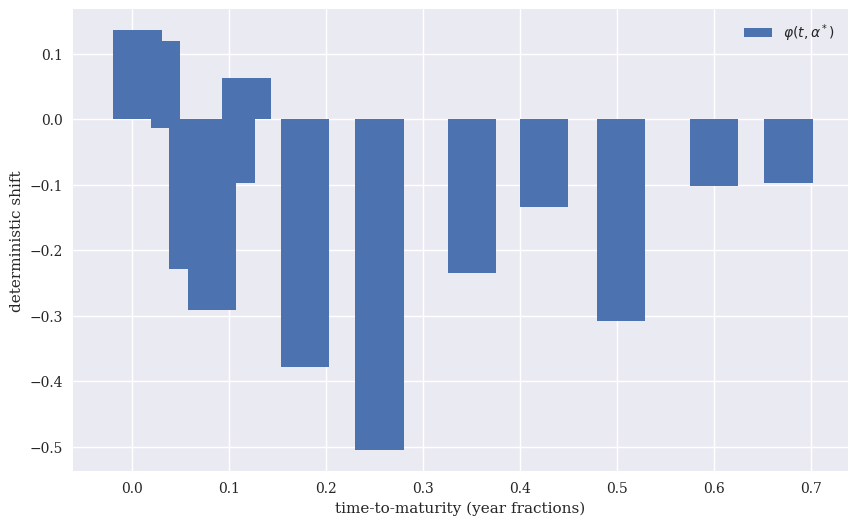

In [66]:
plt.figure(figsize=(10, 6));
plt.bar(ttms, srd_fwds - forwards,
            width=0.05, label='$\\varphi(t,\\alpha^*)$')
plt.legend(loc=0)
plt.xlabel('time-to-maturity (year fractions)')
plt.ylabel('deterministic shift');

Option Valuation by Monte Carlo Simulation

This section implements Monte Carlo simulation procedures for the SRJD model.

Technical Implementation
In view of using a numerical method like MCS for all valuation and calibration tasks, the parametrization and implementation of the MCS algorithm plays an important role. Some major features of our implementation are:

discretization: the algorithm uses the Euler discretization scheme which is an approximation only but which might bring performance benefits
random numbers: for every single option valuation the seed can be held constant such that every option is valued with the same set of (pseudo-) random numbers
variance reduction: both antithetic variates and moment matching (for the first two moments of the pseudo-random numbers) are used as generic variance reduction techniques
deterministic shift: the deterministic shift values 
 are determined only once through a separate calibration and are held constant afterwards (even if model parameters change)

In [84]:
#SRJD MODEL SIMULATION

#This script is used to simulate the SRJD model

import math
import pickle
import numpy as np
import scipy.interpolate as scint

v0 =S0   # initial VIX index level

# parameters of square-root diffusion
kappa = 2.0  # speed of mean reversion
theta = 15.0  # long-term volatility
sigma = 1.0  # standard deviation coefficient

# parameters of log-normal jump
lamb = 0.4  # intensity (jumps per year)
mu = 0.4  # average jump size
delta = 0.1  # volatility of jump size

# general parameters
r = 0.0545  # risk-free interest rate
K = 12  # strike
T = 0.5  # time horizon
M = 150  # time steps
I = 10000  # number of MCS paths
anti_paths = True  # antithetic variates
mo_match = True  # moment matching


# deterministic shift parameters
varphi = pickle.load(open('varphi', 'rb'))
tck = scint.splrep(varphi['ttms'], varphi['varphi'], k=1)

# linear splines interpolation of
# term structure calibration differences


def random_number_gen(M, I, fixed_seed=False):
    ''' Generate standard normally distributed pseudo-random numbers

    Parameters
    ==========
    M: int
        number of time intervals
    I: int
        number of paths

    Returns
    =======
    ran: NumPy ndarrayo object
        random number array
    '''
    if fixed_seed is True:
        np.random.seed(10000)
    if anti_paths is True:
        ran = np.random.standard_normal((M + 1, int(I / 2)))
        ran = np.concatenate((ran, -ran), axis=1)
    else:
        ran = np.standard_normal((M + 1, I))
    if mo_match is True:
        ran = ran / np.std(ran)
        ran -= np.mean(ran)
    return ran


def srjd_simulation(x0, kappa, theta, sigma,
                    lamb, mu, delta, T, M, I, fixed_seed=False):
    ''' Function to simulate square-root jump Difusion.

    Parameters
    ==========
    x0: float
        initial value
    kappa: float
        mean-reversion factor
    theta: float
        long-run mean
    sigma: float
        volatility factor
    lamb: float
        jump intensity
    mu: float
        expected jump size
    delta: float
        standard deviation of jump
    T: float
        time horizon/maturity
    M: int
        time steps
    I: int
        number of simulation paths

    Returns
    =======
    x: NumPy ndarray object
        array with simulated SRJD paths
    '''
    dt = float(T) / M  # time interval
    shift = scint.splev(np.arange(M + 1) * dt, tck, der=0)
      # deterministic shift values
    xh = np.zeros((M + 1, I), dtype=float)
    x = np.zeros((M + 1, I), dtype=float)
    xh[0, :] = x0
    x[0, :] = x0
    # drift contribution of jump p.a.
    rj = lamb * (math.exp(mu + 0.5 * delta ** 2) - 1)
    # 1st matrix with standard normal rv
    ran1 = random_number_gen(M + 1, I, fixed_seed)
    # 2nd matrix with standard normal rv
    ran2 = random_number_gen(M + 1, I, fixed_seed)
    # matrix with Poisson distributed rv
    ran3 = np.random.poisson(lamb * dt, (M + 1, I))
    for t in range(1, M + 1):
        xh[t, :] = (xh[t - 1, :] +
                    kappa * (theta - np.maximum(0, xh[t - 1, :])) * dt
                  + np.sqrt(np.maximum(0, xh[t - 1, :])) * sigma
                  * ran1[t] * np.sqrt(dt)
                  + (np.exp(mu + delta * ran2[t]) - 1) * ran3[t]
                  * np.maximum(0, xh[t - 1, :]) - rj * dt)
        x[t, :] = np.maximum(0, xh[t, :]) + shift[t]
    return x


def srjd_call_valuation(v0, kappa, theta, sigma,
                        lamb, mu, delta, T, r, K, M=M, I=I,
                        fixed_seed=False):
    ''' Function to value European volatility call option in SRDJ model.
    Parameters see function srjd_simulation.

    Returns
    =======
    call_value: float
        estimator for European call present value for strike K
    '''
    v = srjd_simulation(v0, kappa, theta, sigma,
                        lamb, mu, delta, T, M, I, fixed_seed)
    call_value = np.exp(-r * T) * sum(np.maximum(v[-1] - K, 0)) / I
    return call_value

if __name__ == '__main__':
    call_value = srjd_call_valuation(v0, kappa, theta, sigma,
                                    lamb, mu, delta, T, r, K, M, I)
    print("Value of European call by MCS: %10.4f" % call_value)

Value of European call by MCS:     2.9271


Model Calibration

This section now calibrates the SRJD model to market quotes for European call options on VIX futures. 
It considers calibrations to a single maturity as well as to multiple maturities.

The calibration of the SRJD model is similar to the procedure for the Gruenbichler and Lonstaff (1996) square-root diffusion model 

In [125]:
option_data = df.copy()

print(option_data)

         contractSymbol             lastTradeDate  strike  lastPrice   bid  \
0   VIXW240124C00010000 2024-01-03 20:55:33+00:00    10.0       4.80  3.00   
1   VIXW240124C00010500 2024-01-03 20:37:13+00:00    10.5       4.10  2.95   
2   VIXW240124C00011000 2024-01-12 15:04:19+00:00    11.0       2.45  2.46   
3   VIXW240124C00011500 2024-01-12 21:02:51+00:00    11.5       2.10  1.99   
4   VIXW240124C00012000 2024-01-12 20:28:43+00:00    12.0       1.62  1.49   
..                  ...                       ...     ...        ...   ...   
43   VIX240918C00100000 2024-01-09 19:28:12+00:00   100.0       0.23  0.00   
44   VIX240918C00110000 2024-01-03 15:57:43+00:00   110.0       0.27  0.00   
45   VIX240918C00130000 2024-01-12 15:08:57+00:00   130.0       0.17   NaN   
46   VIX240918C00150000 2024-01-10 16:52:59+00:00   150.0       0.11   NaN   
47   VIX240918C00170000 2024-01-08 16:30:32+00:00   170.0       0.14   NaN   

     ask  change  percentChange  volume  openInterest  ...  con

In [129]:
#SRD MODEL CALIBRATION
import scipy.optimize as sco

# Fixed Parameters
v0 = S0  # VSTOXX index on 31. March 2014
r = r  # risk-less short rate
zeta = 0.  # volatility risk premium factor

tol=0.2
''' Selects and read options quotes'''
    #h5 = pd.HDFStore(path + 'vstoxx_march_2014.h5', 'r')

    # read option data from file and close it
    #option_data = h5['vstoxx_options']
    #h5.close()
    
    # transform dates
    #option_data['DATE'] = pd.to_datetime(date)
    #option_data['MATURITY'] = expiration_dates

    # select relevant date for call option quotes
#option_data = option_data[(option_data.DATE == date)
                            #& (option_data.Type == 'c')]
    
# calculate time-to-maturity in year fractions
option_data['TTM']= (option_data['MATURITY'] - option_data['DATE']).dt.days / 365

# only those options close enough to the ATM level
option_data = option_data[(option_data['strike'] > (1 - tol) * v0)
                            & (option_data['strike'] < (1 + tol) * v0)]


def call_price(v0, kappa, theta, sigma, zeta, T, r, K):
    ''' Call option pricing formula in GL96 Model

    Parameters
    ==========
    v0: float (positive)
        current volatility level
    kappa: float (positive)
        mean-reversion factor
    theta: float (positive)
        long-run mean of volatility
    sigma: float (positive)
        volatility of volatility
    zeta: float (positive)
        volatility risk premium
    T: float (positive)
        time-to-maturity
    r: float (positive)
        risk-free short rate
    K: float(positive)
        strike price of the option

    Returns
    =======
    call: float
        present value of European call option
    '''
    D = math.exp(-r * T)  # discount factor

    alpha = kappa * theta
    beta = kappa + zeta
    gamma = 4 * beta / (sigma ** 2 * (1 - math.exp(-beta * T)))
    nu = 4 * alpha / sigma ** 2
    lamb = gamma * math.exp(-beta * T) * v0

    # the pricing formula
    call = (D * math.exp(-beta * T) * v0 * cx(K, gamma, nu + 4, lamb)
      + D * (alpha / beta) * (1 - math.exp(-beta * T))
      * cx(K, gamma, nu + 2, lamb)
      - D * K * cx(K, gamma, nu, lamb))
    return call


def valuation_function(p0):
    ''' Valuation function for set of strike prices

    Parameters
    ==========
    p0: list
        set of model parameters

    Returns
    =======
    call_prices: NumPy ndarray object
        array of call prices
    '''
    kappa, theta, sigma = p0
    call_prices = []
    for strike in strikes:
        call_prices.append(call_price(v0, kappa, theta,
                                   sigma, zeta, TTM, r, strike))
    call_prices = np.array(call_prices)
    return call_prices


def error_function(p0):
    ''' Error function for model calibration.

    Parameters
    ==========
    p0: tuple
        set of model parameters

    Returns
    =======
    MSE: float
        mean squared (relative/absolute) error
    '''
    global i
    call_prices = valuation_function(p0)
    kappa, theta, sigma = p0
    pen = 0.
    if 2 * kappa * theta < sigma ** 2:
        pen = 1000.0
    if kappa < 0 or theta < 0 or sigma < 0:
        pen = 1000.0
    if relative is True:
        MSE = (np.sum(((call_prices - call_quotes) / call_quotes) ** 2)
                / len(call_quotes) + pen)
    else:
        MSE = np.sum((call_prices - call_quotes) ** 2) / len(call_quotes) + pen

    if i == 0:
            print("{:>6s} {:>6s} {:>6s}".format('kappa', 'theta', 'sigma')
                 + "{:>12s}".format('MSE'))

    # print intermediate results: every 100th iteration
    if i % 100 == 0:
        print("{:6.3f} {:6.3f} {:6.3f}".format(*p0) + "{:>12.5f}".format(MSE))
    i += 1
    return MSE


def model_calibration(option_data, rel=False, mat='2024-04-17'):
    ''' Function for global and local model calibration.

    Parameters
    ==========
    option_data: pandas DataFrame object
        option quotes to be used
    relative: boolean
        relative or absolute MSE
    maturity: string
        maturity of option quotes to calibrate to

    Returns
    =======
    opt: tuple
        optimal parameter values
    '''
    global relative  # if True: MSRE is used, if False: MSAE
    global strikes
    global call_quotes
    global TTM
    global i

    relative = rel
    # only option quotes for a single maturity
    option_quotes = option_data[option_data.MATURITY == mat]

    # time-to-maturity from the data set
    TTM = option_quotes['TTM'].values

    # transform strike column and price column in ndarray object
    strikes = option_quotes['strike'].values
    call_quotes = option_quotes['lastPrice'].values

    # global optimization
    i = 0  # counter for calibration iterations
    p0 = sco.brute(error_function, ((5.0, 20.1, 1.0), (10., 30.1, 1.25),
                             (1.0, 9.1, 2.0)), finish=None)

    # local optimization
    i = 0
    opt = sco.fmin(error_function, p0, xtol=0.0000001, ftol=0.0000001,
                                 maxiter=1000, maxfun=1500)

    return opt


def plot_calibration_results(opt):
    ''' Function to plot market quotes vs. model prices.

    Parameters
    ==========
    opt: list
        optimal parameters from calibration
    '''
    callalues = valuation_function(opt)
    diffs = callalues - call_quotes
    plt.figure()
    plt.subplot(211)
    plt.plot(strikes, call_quotes, label='market quotes')
    plt.plot(strikes, callalues, 'ro', label='model prices')
    plt.ylabel('option values')
    plt.grid(True)
    plt.legend()
    plt.axis([min(strikes) - 0.5, max(strikes) + 0.5,
          0.0, max(call_quotes) * 1.1])
    plt.subplot(212)
    wi = 0.3
    plt.bar(strikes, diffs, width=wi)
    plt.grid(True)
    plt.xlabel('strike price')
    plt.ylabel('difference')
    plt.axis([min(strikes) - 0.5, max(strikes) + 0.5,
          min(diffs) * 1.1, max(diffs) * 1.1])
    plt.tight_layout()

#if __name__ == '__main__':
    #option_data = read_select_quotes()
    opt = model_calibration(option_data=option_data)

print(opt)

[ 2.04012096 38.46171653  0.        ]


In [152]:
#calibration SRDJ model to the VIX European call option quotes


#from srd_model_calibration import path, read_select_quotes
#from srjd_simulation import srjd_call_valuation

# fixed parameters
#r = 0.01  # risk-less short rate
#v0 = 17.6639  # VSTOXX index at 31.03.2014
M = 15  # number of time intervals
I = 100  # number of simulated paths


def srjd_valuation_function(p0):
    ''' Valuation ('difference') function for all options
        of a given DataFrame object.

    Parameters
    ==========
    p0: list
        set of model parameters

    Returns
    =======
    diffs: NumPy ndarray object
        array with valuation differences
    '''
    global relative, option_data
    kappa, theta, sigma, lamb, mu, delta = p0
    diffs = []
    for i, option in option_data.iterrows():
        value = srjd_call_valuation(v0, kappa, theta, sigma,
                                    lamb, mu, delta,
                                    option['TTM'], r, option['STRIKE'],
                                    M=M, I=I, fixed_seed=True)
        if relative is True:
            diffs.append((value - option['PRICE']) / option['PRICE'])
        else:
            diffs.append(value - option['PRICE'])
    diffs = np.array(diffs)
    return diffs


def srjd_error_function(p0):
    ''' Error function for model calibration.

    Parameters
    ==========
    p0: tuple
        set of model parameters

    Returns
    =======
    MSE: float
        mean squared (relative/absolute) error
    '''
    global i, min_MSE, option_data
    OD = len(option_data)
    diffs = srjd_valuation_function(p0)
    kappa, theta, sigma, lamb, mu, delta = p0

    # penalties
    pen = 0.
    if 2 * kappa * theta < sigma ** 2:
        pen = 1000.0
    if kappa < 0 or theta < 0 or sigma < 0 or lamb < 0 or delta < 0:
        pen = 1000.0

    MSE = np.sum(diffs ** 2) / OD + pen  # mean squared error

    min_MSE = min(min_MSE, MSE)  # running minimum value

    if i == 0:
        print('\n' + ('{:>5s}'.format('its')
                      + '{:>7s} {:>6s} {:>6s} {:>6s} {:>6s} {:>6s}'.format(
            'kappa', 'theta', 'sigma', 'lamb', 'mu', 'delta')
            + '{:>12s}'.format('MSE') + '{:>12s}'.format('min_MSE')))
    # print intermediate results: every 100th iteration
    if i % 100 == 0:
        print('{:>5d}'.format(i)
               + '{:7.3f} {:6.3f} {:6.3f} {:6.3f} {:6.3f} {:6.3f}'.format(*p0)
               + '{:>12.5f}'.format(MSE) + '{:>12.5f}'.format(min_MSE))
    i += 1
    return MSE


def srjd_model_calibration(data, p0=None, rel=False, mats=None):
    ''' Function for global and local model calibration.

    Parameters
    ==========
    option_data: pandas DataFrame object
        option quotes to be used
    relative: bool
        relative or absolute MSE
    mats: list
        list of maturities of option quotes to calibrate to

    Returns
    =======
    opt: tuple
        optimal parameter values
    '''
    global i, min_MSE, option_data
    global relative  # if True: MSRE is used, if False: MSAE

    min_MSE = 5000.  # dummy value
    relative = rel  # relative or absolute
    option_data = data

    if mats is not None:
        # select the option data for the given maturities
        option_data = option_data[option_data['MATURITY'].isin(mats)]

    # global optimization
    if p0 is None:
        i = 0  # counter for calibration iterations
        p0 = sco.brute(srjd_error_function, (
            (1.0, 9.1, 4.0),  # kappa
            (10., 20.1, 10.0),  # theta
            (1.0, 3.1, 2.0),  # sigma
            (0.0, 0.81, 0.4),  # lambda
            (-0.2, 0.41, 0.3),  # mu
            (0.0, 0.31, 0.15)),  # delta
            finish=None)

    # local optimization
    i = 0
    opt = sco.fmin(srjd_error_function, p0,
                   xtol=0.0000001, ftol=0.0000001,
                   maxiter=550, maxfun=700)

    return opt


def plot_calibration_results(option_data, opt, mats):
    ''' Function to plot market quotes vs. model prices.

    Parameters
    ==========
    option_data: pandas DataFrame object
        option data to plot
    opt: list
        optimal results from calibration
    mats: list
        maturities to be plotted
    '''
    kappa, theta, sigma, lamb, mu, delta = opt
    # adding model values for optimal parameter set
    # to the DataFrame object
    values = []
    for i, option in option_data.iterrows():
        value = srjd_call_valuation(v0, kappa, theta, sigma,
                                    lamb, mu, delta,
                                    option['TTM'], r, option['STRIKE'],
                                    M=M, I=I, fixed_seed=True)
        values.append(value)
    option_data['MODEL'] = values

    # plotting the market and model values
    height = min(len(mats) * 3, 12)
    fig, axarr = plt.subplots(len(mats), 2, sharex=True, figsize=(10, height))
    for z, mat in enumerate(mats):
        if z == 0:
            axarr[z, 0].set_title('values')
            axarr[z, 1].set_title('differences')
        os = option_data[option_data.MATURITY == mat]
        strikes = os.strike.values
        axarr[z, 0].set_ylabel('%s' % str(mat)[:10])
        axarr[z, 0].plot(strikes, os.lastPrice.values, label='market quotes')
        axarr[z, 0].plot(strikes, os.MODEL.values, 'ro', label='model prices')
        axarr[z, 0].legend(loc=0)
        wi = 0.3
        axarr[z, 1].bar(strikes, os.MODEL.values - os.lastPrice.values,
                        width=wi)
        if mat == mats[-1]:
            axarr[z, 0].set_xlabel('strike')
            axarr[z, 1].set_xlabel('strike')

#if __name__ == '__main__':
    #option_data = read_select_quotes('../data/', tol=0.1)
    #option_data['VALUE'] = 0.0
    opt = srjd_model_calibration()

In [133]:
opt_1 = srjd_model_calibration(option_data, p0=None,
                               rel=False, mats=['2024-4-17'])


  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  100  1.000 20.000  3.000  0.800 -0.200  0.150         nan  5000.00000
  200  5.000 20.000  3.000  0.400 -0.200  0.300         nan  5000.00000
  300  9.000 20.000  3.000  0.000  0.100  0.000         nan  5000.00000

  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  100  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  200  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  300  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  400  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  500  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  600  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000


In [134]:
opt_1

array([ 1. , 10. ,  1. ,  0. , -0.2,  0. ])

In [135]:
values = []
kappa, theta, sigma, lamb, mu, delta = opt_1
for i, option in option_data.iterrows():
    value = srjd_call_valuation(v0, kappa, theta, sigma,
                                lamb, mu, delta,
                                option['TTM'], r, option['STRIKE'],
                                M=M, I=I, fixed_seed=True)
    values.append(value)
option_data['MODEL'] = values

In [144]:
## selecting the data for the shortest maturity
os = option_data[option_data.MATURITY == '2024-4-17']
## selecting corresponding strike prices
strikes = os.strike.values
## comparing the model prices with the market quotes
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6));
ax[0].plot(strikes, os.lastPrice.values, label='market quotes');
ax[0].plot(strikes, os.MODEL.values, 'ro', label='model prices');
ax[0].legend()
ax[1].bar(strikes, os.MODEL.values - os.lastPrice.values,width=0.3);
plt.show()

In [145]:
%%time
opt_8_MSAE = srjd_model_calibration(option_data,
                                rel=False, mats=mats)


  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  100  1.000 20.000  3.000  0.800 -0.200  0.150         nan  5000.00000
  200  5.000 20.000  3.000  0.400 -0.200  0.300         nan  5000.00000
  300  9.000 20.000  3.000  0.000  0.100  0.000         nan  5000.00000

  its  kappa  theta  sigma   lamb     mu  delta         MSE     min_MSE
    0  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  100  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  200  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  300  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  400  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  500  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
  600  1.000 10.000  1.000  0.000 -0.200  0.000         nan  5000.00000
CPU times: user 319 ms, sys: 26.2 ms, total: 345 ms
Wall time:

In [153]:
opt_8_MSAE

array([ 1. , 10. ,  1. ,  0. , -0.2,  0. ])

In [154]:
plot_calibration_results(option_data, opt_8_MSAE, mats)


TypeError: srjd_model_calibration() missing 1 required positional argument: 'data'